<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier0_alignment_laws_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tier 0 — Validating the Alignment Laws

**What this notebook is.** The cheapest, most important experiment in the PIHL post-training plan: a *falsification test* for the two laws that everything downstream rests on. It runs on a **Colab CPU runtime in about a minute** — no GPU, no diffusion model, no dataset.

**Why run it first.** The whole program claims that a local, backprop-free (zeroth-order) rule can post-train a model *because the variance is affordable*. That affordability is a formula. If the formula is wrong, we want to find out on a CPU in one minute — not after burning A100 or TPU hours. This is the "prove-before-training" discipline (mentor decision D5) turned into code.

**The two claims we test.** For a zeroth-order estimator that averages $M$ random probes, the squared cosine between the *estimated* gradient and the *true* gradient is:

$$\underbrace{\cos^2\theta=\frac{M}{M+P+1}}_{\textbf{weight perturbation}}\qquad\qquad \underbrace{\cos^2\theta=\frac{M}{M+\bar d+1}}_{\textbf{node perturbation}}$$

- $P=r(m+n)$ is the **weight count** of a LoRA adapter — the effective dimension when you perturb *weights*.
- $\bar d=(1-\beta)\,r+\beta\,m$ is the **energy-weighted node dimension** when you perturb *activations*, where $\beta=\dfrac{\lVert\partial_B L\rVert^2}{\lVert\partial_A L\rVert^2+\lVert\partial_B L\rVert^2}$ is the fraction of the adapter's gradient energy sitting in $B$.

For a LoRA adapter $\bar d\le m\ll P$, so node perturbation should reach the same alignment with **far fewer probes**. That prediction is what we're checking.

**A pass looks like:** the measured dots land on the predicted curves, and the node-perturbation dimension $\bar d$ (computed from a *measured* $\beta$) is dramatically smaller than $P$.


## Step 0 — Environment

Tier 0 needs only `numpy` and `matplotlib` (both preinstalled in Colab). Nothing to `pip install`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)   # fixed seed -> reproducible
print("ready")

ready


## Step 1 — Build a LoRA-adapted network

We don't need a diffusion model to test the *estimator geometry* — we need a realistic **nonlinear loss** with a **LoRA adapter** whose two node sites we can perturb. The smallest honest thing:

$$z = A x \;\;(\text{bottleneck, } r\text{-dim}) \qquad u = B z \;\;(\text{adapter output, } m\text{-dim})$$
$$p = W_0 x + u \qquad h = \tanh(p) \qquad \text{out} = C h \qquad L = \tfrac12\lVert \text{out} - t\rVert^2$$

- $W_0$ is the **frozen backbone** weight; $A\in\mathbb{R}^{r\times n}$ and $B\in\mathbb{R}^{m\times r}$ are the **trainable LoRA adapter**.
- The two **node sites** are the bottleneck $z$ (dimension $r$) and the adapter output $u$ (dimension $m$). Node perturbation injects noise here; weight perturbation injects noise into $A,B$ directly.
- The $\tanh$ and the head $C$ make the loss genuinely nonlinear, so this is not a rigged linear toy.

`forward()` returns the loss and lets us optionally **inject a perturbed node activation** (`z_override` / `u_override`) using forward passes only — exactly what a backprop-free rule is allowed to do.


In [2]:
n, m, r, k = 100, 64, 8, 10      # in-dim, adapted out-dim, LoRA rank, head-dim
mu = 1e-4                         # finite-difference step for zeroth-order probes

# frozen backbone + trainable adapter + fixed head / input / target
W0 = rng.standard_normal((m, n)) / np.sqrt(n)
A  = rng.standard_normal((r, n)) / np.sqrt(n)
B  = rng.standard_normal((m, r)) / np.sqrt(r)
C  = rng.standard_normal((k, m)) / np.sqrt(m)
x  = rng.standard_normal(n)
t  = rng.standard_normal(k)

def forward(A_, B_, z_override=None, u_override=None):
    z = A_ @ x
    if z_override is not None: z = z_override
    u = B_ @ z
    if u_override is not None: u = u_override
    p = W0 @ x + u
    h = np.tanh(p)
    out = C @ h
    return 0.5 * np.sum((out - t) ** 2), z, u, p, h, out

print("model built:  P = r(m+n) =", r*(m+n))

model built:  P = r(m+n) = 1312


## Step 2 — Ground-truth gradients (exact backprop)

To *measure* alignment we need the true gradient to compare against. In the real experiment gradients come from zeroth-order probes; here we also compute the exact gradient by hand so we have a reference. The chain, following the model above:

$$\frac{\partial L}{\partial u}=g_u,\qquad \frac{\partial L}{\partial z}=B^\top g_u=g_z,\qquad \frac{\partial L}{\partial A}=g_z x^\top,\qquad \frac{\partial L}{\partial B}=g_u z^\top.$$

From the two gradient blocks we compute the energy split $\beta$ and therefore the two effective dimensions $P$ and $\bar d$ we're about to test.


In [3]:
L0, z0, u0, p0, h0, out0 = forward(A, B)

dout = out0 - t
dh   = C.T @ dout
dp   = dh * (1 - h0**2)     # tanh'
g_u  = dp                  # dL/du
g_z  = B.T @ g_u           # dL/dz
gA   = np.outer(g_z, x)    # dL/dA
gB   = np.outer(g_u, z0)   # dL/dB
g    = np.concatenate([gA.ravel(), gB.ravel()])   # full adapter gradient (flat)
gn2  = g @ g

E_A, E_B = np.sum(gA**2), np.sum(gB**2)
beta = E_B / (E_A + E_B)
dbar = (1 - beta) * r + beta * m
P    = r * (m + n)

print(f"beta (gradient energy in B) = {beta:.4f}")
print(f"weight-space effective dim  P    = {P}")
print(f"node-space   effective dim  dbar = {dbar:.2f}   ->  {P/dbar:.1f}x smaller")

beta (gradient energy in B) = 0.2168
weight-space effective dim  P    = 1312
node-space   effective dim  dbar = 20.14   ->  65.1x smaller


**Read the output.** $\bar d$ is an energy-weighted *barycenter* of the two site dimensions $r=8$ and $m=64$, not a weight count. With most gradient energy near the bottleneck, $\bar d$ sits close to $r$, and it is an order of magnitude (or two) below $P$. That gap is the entire promise of node perturbation — the next steps check it's real.

## Step 3 — The two zeroth-order estimators

Both are **antithetic two-point** estimators: probe with a random direction, evaluate the loss at $+\mu$ and $-\mu$, and scale the direction by the finite-difference slope. Forward passes only — no backward pass, no activation tape.

- **Weight perturbation** injects noise into the parameters $A,B$. Its variance scales with the *number of weights* $P$.
- **Node perturbation** injects noise into the *activations* $z$ (the $r$-dim bottleneck) and $u$ (the $m$-dim output), forming a per-site estimate. Its variance scales with the *node* dimension $\bar d$. This is the faithful form of the program's three-factor rule $\Delta w = \eta\,(\text{pre})(\text{post-noise})(\text{broadcast})$ — the outer products below are literally that rule.


In [4]:
def zo_weight_probe():
    xiA = rng.standard_normal((r, n)); xiB = rng.standard_normal((m, r))
    Lp, *_ = forward(A + mu*xiA, B + mu*xiB)
    Lm, *_ = forward(A - mu*xiA, B - mu*xiB)
    d = (Lp - Lm) / (2*mu)
    return np.concatenate([(d*xiA).ravel(), (d*xiB).ravel()])

def zo_node_probe():
    # site 1: perturb bottleneck z (r-dim) -> estimate g_z (total derivative through u,p,h)
    xi_z = rng.standard_normal(r)
    Lp, *_ = forward(A, B, z_override=z0 + mu*xi_z)
    Lm, *_ = forward(A, B, z_override=z0 - mu*xi_z)
    gz_hat = ((Lp - Lm)/(2*mu)) * xi_z
    # site 2: perturb adapter output u (m-dim) -> estimate g_u
    xi_u = rng.standard_normal(m)
    Lp, *_ = forward(A, B, u_override=u0 + mu*xi_u)
    Lm, *_ = forward(A, B, u_override=u0 - mu*xi_u)
    gu_hat = ((Lp - Lm)/(2*mu)) * xi_u
    # three-factor updates: outer(node-signal, presynaptic-activity)
    eA = np.outer(gz_hat, x); eB = np.outer(gu_hat, z0)
    return np.concatenate([eA.ravel(), eB.ravel()])

print("estimators defined")

estimators defined


## Step 4 — Measure alignment vs probe budget $M$

For each probe budget $M$ we average $M$ probes into one gradient estimate and compute the **signal-to-energy alignment**

$$\cos^2\theta=\frac{\big(\mathbb E[\hat g_M^\top g]\big)^2}{\lVert g\rVert^2\,\mathbb E[\lVert\hat g_M\rVert^2]},$$

estimating the two expectations by averaging over many repetitions. Then we compare to the predicted `M/(M+P+1)` and `M/(M+dbar+1)`.


In [5]:
def alignment_curve(probe_fn, Ms, reps):
    out = {}
    for M in Ms:
        num = den = 0.0
        for _ in range(reps):
            acc = np.zeros_like(g)
            for _ in range(M):
                acc += probe_fn()
            acc /= M
            num += acc @ g
            den += acc @ acc
        num /= reps; den /= reps
        out[M] = (num**2) / (gn2 * den)
    return out

Ms, reps = [1, 4, 16, 64, 256], 3000
cw = alignment_curve(zo_weight_probe, Ms, reps)
cn = alignment_curve(zo_node_probe,   Ms, reps)

print(f"{'M':>4} | {'weight cos^2':>12} {'M/(M+P+1)':>11} | {'node cos^2':>11} {'M/(M+dbar+1)':>13}")
for M in Ms:
    print(f"{M:>4} | {cw[M]:>12.4f} {M/(M+P+1):>11.4f} | {cn[M]:>11.4f} {M/(M+dbar+1):>13.4f}")

   M | weight cos^2   M/(M+P+1) |  node cos^2  M/(M+dbar+1)
   1 |       0.0008      0.0008 |      0.0444        0.0452
   4 |       0.0031      0.0030 |      0.1588        0.1591
  16 |       0.0120      0.0120 |      0.4309        0.4308
  64 |       0.0462      0.0465 |      0.7499        0.7517
 256 |       0.1631      0.1632 |      0.9231        0.9237


## Step 5 — Plot and interpret

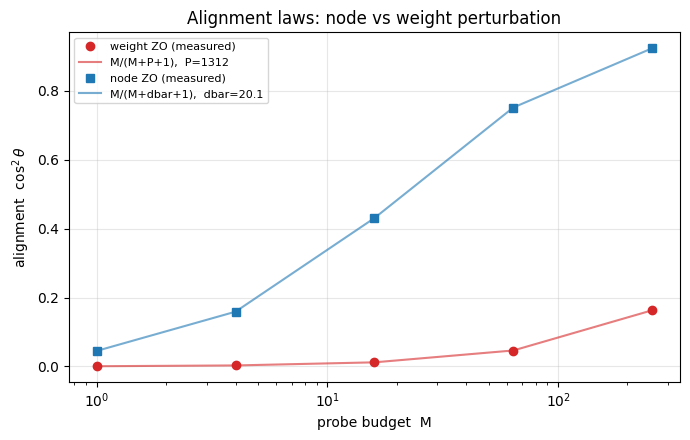

In [6]:
Mg = np.array(Ms)
plt.figure(figsize=(7, 4.5))
plt.plot(Mg, [cw[M] for M in Ms], "o", color="C3", label="weight ZO (measured)")
plt.plot(Mg, Mg/(Mg+P+1), "-", color="C3", alpha=.6, label=f"M/(M+P+1),  P={P}")
plt.plot(Mg, [cn[M] for M in Ms], "s", color="C0", label="node ZO (measured)")
plt.plot(Mg, Mg/(Mg+dbar+1), "-", color="C0", alpha=.6, label=f"M/(M+dbar+1),  dbar={dbar:.1f}")
plt.xscale("log"); plt.xlabel("probe budget  M"); plt.ylabel(r"alignment  $\cos^2\theta$")
plt.title("Alignment laws: node vs weight perturbation")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### How to read this

**Pass:** each set of dots sits on its predicted curve, and the blue (node) curve rises far faster than the red (weight) curve — same forward-pass primitive, an order-of-magnitude fewer probes to the same alignment. That is the theory surviving contact with a real nonlinear loss and *finite* $\mu$ (not the idealized $\mu\to0$ limit).

**Falsification — if it does *not* pass, suspect (in order):**
1. **Finite-$\mu$ bias** — the two-point estimate has $O(\mu^2)$ bias. Re-run with a smaller `mu` (e.g. `1e-5`) in float64; if the dots move onto the curves, that was it.
2. **Wrong effective dimension** — if node dots follow `M/(M+d+1)` for some $d\ne\bar d$, then $\beta$ or the site accounting is off. Print $E_A,E_B$ and check.
3. **Site-coupling leakage** — if you ever perturb both sites in one pass, cross-terms inflate the variance; the clean law needs the two sites probed separately (as coded here).


## Step 6 (optional) — Feel the rank dependence

$\bar d$ depends on the LoRA rank $r$ and on where the gradient energy lands. This cell recomputes $P$ and $\bar d$ (closed form — no probing, instant) across a few ranks, previewing the Stage-B rank sweep: notice $P$ grows like $r(m+n)$ while $\bar d$ stays between $r$ and $m$.


In [7]:
print(f"{'r':>4} {'P=r(m+n)':>10} {'beta':>7} {'dbar':>7} {'P/dbar':>8}")
for rr in [2, 4, 8, 16, 32]:
    Ar = rng.standard_normal((rr, n)) / np.sqrt(n)
    Br = rng.standard_normal((m, rr)) / np.sqrt(rr)
    zr = Ar @ x; ur = Br @ zr
    pr = W0 @ x + ur; hr = np.tanh(pr); outr = C @ hr
    dpr = (C.T @ (outr - t)) * (1 - hr**2)
    guR = dpr; gzR = Br.T @ guR
    EAr = np.sum(np.outer(gzR, x)**2); EBr = np.sum(np.outer(guR, zr)**2)
    bR = EBr/(EAr+EBr); dR = (1-bR)*rr + bR*m
    print(f"{rr:>4} {rr*(m+n):>10} {bR:>7.3f} {dR:>7.2f} {rr*(m+n)/dR:>8.1f}")

   r   P=r(m+n)    beta    dbar   P/dbar
   2        328   0.066    6.11     53.7
   4        656   0.034    6.02    109.0
   8       1312   0.243   21.62     60.7
  16       2624   0.190   25.10    104.5
  32       5248   0.227   39.26    133.7


## What Tier 0 established, and what's next

**Established (on a CPU, in ~1 minute):** both alignment laws hold on a real nonlinear loss with forward-pass-only probes, and node perturbation gives a large ($\sim\!P/\bar d$) reduction in effective dimension. The core variance claim of the program is not an artifact of the idealized derivation.

**Not yet established (that's Tier 1, on a T4/L4 GPU):**
- Does this hold on an actual **diffusion denoiser** (small UNet/DiT) with LoRA adapters, trained on MNIST/CIFAR?
- Does the **Stage-B rank sweep** match the Eckart–Young prediction — captured loss saturating at the singular-value **knee** $r^\ast$ of the backprop-LoRA control's update?
- Is the knee **estimator-independent** (same $r^\ast$ for weight, node-per-site, and node-output-only)? If not, the estimator is contaminating the approximation floor.

**Integrity rule:** don't spend A100/TPU hours until Tier 1 on a free T4 reproduces the laws with a *measured* $\bar d$ and a stable knee.
